In [1]:
from pathlib import Path
import pandas as pd

# Resolve the project root whether Jupyter starts in the repository root
# or inside the notebooks directory.
current_dir = Path.cwd()
if (current_dir / 'data' / 'results.csv').exists():
    project_root = current_dir
elif (current_dir.parent / 'data' / 'results.csv').exists():
    project_root = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not locate data/results.csv. Start Jupyter from the project folder "
        "or keep the repository structure unchanged."
    )

results_path = project_root / 'data' / 'results.csv'

# Load the dataset and convert dates.
df_matches = pd.read_csv(results_path)
df_matches['date'] = pd.to_datetime(df_matches['date'])

print("Project root:", project_root)
print("Dataset path:", results_path)
print("Dataset Shape:", df_matches.shape)
display(df_matches.head())


Project root: C:\Users\gurij\Documents\UCD MSC\Sem 3\Final Project\World_Cup_Predictor_Commit_03_Project_Structure\World_Cup_Predictor_Commit_03_Project_Structure
Dataset path: C:\Users\gurij\Documents\UCD MSC\Sem 3\Final Project\World_Cup_Predictor_Commit_03_Project_Structure\World_Cup_Predictor_Commit_03_Project_Structure\data\results.csv
Dataset Shape: (49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [2]:
#Dropping any rows where the match didn't happen or scores are missing
df_matches = df_matches.dropna(subset=['home_score', 'away_score']).copy()

#Filtering for the modern era that is post the year 2000
modern_era_cutoff = '2000-01-01'
df_clean = df_matches[df_matches['date'] >= modern_era_cutoff].copy()

#Checking the type of tournaments
print("Total matches after 2000:", df_clean.shape[0])
print("\nTop 10 Tournament Types:")
print(df_clean['tournament'].value_counts().head(10))

Total matches after 2000: 25157

Top 10 Tournament Types:
tournament
Friendly                                8316
FIFA World Cup qualification            5840
UEFA Euro qualification                 1532
African Cup of Nations qualification    1416
UEFA Nations League                      658
AFC Asian Cup qualification              530
African Cup of Nations                   525
CONCACAF Nations League                  422
FIFA World Cup                           384
Gold Cup                                 359
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np

#Splitting the data into Home and Away perspectives
df_home = df_clean[['date', 'home_team', 'home_score', 'away_score']].copy()
df_home = df_home.rename(columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'})

df_away = df_clean[['date', 'away_team', 'away_score', 'home_score']].copy()
df_away = df_away.rename(columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'})
df_team_matches = pd.concat([df_home, df_away]).sort_values(by=['team', 'date']).reset_index(drop=True)

#Calculating Rolling Form (Average goals scored/conceded in the previous 5 matches) using shift() to ensure we don't include current match result
window_size = 5

df_team_matches['form_goals_for'] = df_team_matches.groupby('team')['goals_for'].transform(
    lambda x: x.shift().rolling(window=window_size, min_periods=1).mean()
)

df_team_matches['form_goals_against'] = df_team_matches.groupby('team')['goals_against'].transform(
    lambda x: x.shift().rolling(window=window_size, min_periods=1).mean()
)

#Filling any early NA values (teams playing their first few matches) with 0
df_team_matches = df_team_matches.fillna(0)

#Sanity check
print("Argentina's Form Check:")
display(df_team_matches[df_team_matches['team'] == 'Argentina'].tail(10))

Argentina's Form Check:


,date,team,goals_for,goals_against,form_goals_for,form_goals_against
1859,2025-03-25,Argentina,4.0,1.0,2.0,0.6
1860,2025-06-05,Argentina,1.0,0.0,2.6,0.6
1861,2025-06-10,Argentina,1.0,1.0,1.6,0.6
1862,2025-09-04,Argentina,3.0,0.0,1.6,0.4
1863,2025-09-09,Argentina,0.0,1.0,2.0,0.4
1864,2025-10-10,Argentina,1.0,0.0,1.8,0.6
1865,2025-10-14,Argentina,6.0,0.0,1.2,0.4
1866,2025-11-14,Argentina,2.0,0.0,2.2,0.4
1867,2026-03-27,Argentina,2.0,1.0,2.4,0.2
1868,2026-03-31,Argentina,5.0,0.0,2.2,0.4


In [4]:
#Isolating just the form columns we want to bring over
df_form_only = df_team_matches[['date', 'team', 'form_goals_for', 'form_goals_against']]

#Merging form data for the Home Team
df_model = pd.merge(
    df_clean,
    df_form_only,
    left_on=['date', 'home_team'],
    right_on=['date', 'team'],
    how='left'
).rename(columns={
    'form_goals_for': 'home_form_goals_for',
    'form_goals_against': 'home_form_goals_against'
}).drop('team', axis=1)

#Merging form data for the Away Team
df_model = pd.merge(
    df_model,
    df_form_only,
    left_on=['date', 'away_team'],
    right_on=['date', 'team'],
    how='left'
).rename(columns={
    'form_goals_for': 'away_form_goals_for',
    'form_goals_against': 'away_form_goals_against'
}).drop('team', axis=1)

# Creating the Target Variable (y) for our classification model
#Encoding - 2 = Home Win, 1 = Draw, 0 = Away Win
conditions = [
    (df_model['home_score'] > df_model['away_score']),
    (df_model['home_score'] == df_model['away_score']),
    (df_model['home_score'] < df_model['away_score'])
]
choices = [2, 1, 0]
df_model['target'] = np.select(conditions, choices, default=np.nan)

#Cleaing up any NaNs that might have slipped through the merge
df_model = df_model.dropna()

print("Final Feature Matrix Shape:", df_model.shape)
display(df_model[['date', 'home_team', 'away_team', 'home_form_goals_for', 'away_form_goals_for', 'target']].tail())

Final Feature Matrix Shape: (25171, 14)


,date,home_team,away_team,home_form_goals_for,away_form_goals_for,target
25166,2026-03-31,Kosovo,Turkey,1.6,3.0,0.0
25167,2026-03-31,Czech Republic,Denmark,2.0,3.4,1.0
25168,2026-03-31,Cameroon,China PR,1.0,1.0,2.0
25169,2026-03-31,Australia,Curaçao,0.6,2.0,2.0
25170,2026-03-31,Kazakhstan,Comoros,1.6,0.2,2.0


In [5]:
import numpy as np
import pandas as pd

#Applying weights and neutral flags to df_clean
def get_tournament_weight(tournament_name):
    if 'FIFA World Cup' in tournament_name and 'qualification' not in tournament_name:
        return 1.0
    elif 'Confederations Cup' in tournament_name or 'Copa America' in tournament_name or 'Euro' in tournament_name and 'qualification' not in tournament_name:
        return 0.8
    elif 'qualification' in tournament_name:
        return 0.6
    elif 'Nations League' in tournament_name:
        return 0.5
    elif 'Friendly' in tournament_name:
        return 0.25
    else:
        return 0.4

df_clean['match_weight'] = df_clean['tournament'].apply(get_tournament_weight)
df_clean['is_neutral'] = df_clean['neutral'].astype(int)

#Re running the Step 4 Merge so df_model inherits the new columns
df_model = pd.merge(
    df_clean, df_form_only,
    left_on=['date', 'home_team'], right_on=['date', 'team'], how='left'
).rename(columns={'form_goals_for': 'home_form_goals_for', 'form_goals_against': 'home_form_goals_against'}).drop('team', axis=1)

df_model = pd.merge(
    df_model, df_form_only,
    left_on=['date', 'away_team'], right_on=['date', 'team'], how='left'
).rename(columns={'form_goals_for': 'away_form_goals_for', 'form_goals_against': 'away_form_goals_against'}).drop('team', axis=1)

#Re applying the target variable
conditions = [
    (df_model['home_score'] > df_model['away_score']),
    (df_model['home_score'] == df_model['away_score']),
    (df_model['home_score'] < df_model['away_score'])
]
df_model['target'] = np.select(conditions, [2, 1, 0], default=np.nan)
df_model = df_model.dropna()

#Defining X and y for the SVM (This will now work perfectly!)
features = [
    'home_form_goals_for', 'home_form_goals_against',
    'away_form_goals_for', 'away_form_goals_against',
    'match_weight', 'is_neutral'
]
X = df_model[features]
y = df_model['target']

print("Success! The missing columns are injected.")
print("Shape of Feature Matrix (X):", X.shape)
print("Shape of Target Vector (y):", y.shape)

Success! The missing columns are injected.
Shape of Feature Matrix (X): (25171, 6)
Shape of Target Vector (y): (25171,)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# 1. Define our Feature Matrix (X) and Target Vector (y)
# We isolate only the predictive numeric columns, dropping metadata like dates and names
features = [
    'home_form_goals_for', 'home_form_goals_against',
    'away_form_goals_for', 'away_form_goals_against',
    'match_weight', 'is_neutral'
]

X = df_model[features]
y = df_model['target']

# 2. Split the pitch: 80% for training, 20% for testing our predictions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the data so the SVM hyperplanes aren't distorted
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the model WITH balanced class weights
print("Retraining the SVM with balanced weights...")
svm_model_balanced = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_model_balanced.fit(X_train_scaled, y_train)

# 5. Evaluate the newly balanced model
y_pred_balanced = svm_model_balanced.predict(X_test_scaled)
print("\n--- Balanced Model Evaluation ---")
print(classification_report(y_test, y_pred_balanced, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

Retraining the SVM with balanced weights...

--- Balanced Model Evaluation ---
              precision    recall  f1-score   support

Away Win (0)       0.45      0.47      0.46      1407
    Draw (1)       0.28      0.41      0.34      1197
Home Win (2)       0.65      0.50      0.56      2431

    accuracy                           0.47      5035
   macro avg       0.46      0.46      0.45      5035
weighted avg       0.51      0.47      0.48      5035



In [7]:
# 1. Define standard Elo mathematical functions
def get_expected_score(rating_a, rating_b):
    # Calculates the probability of Team A winning based on Elo difference
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def update_elo(rating, expected, actual, k=30):
    # k is the weight of the match.
    return rating + k * (actual - expected)

# 2. Initialize a dictionary to track everyone's live rating (Baseline is 1500)
current_elo = {}

home_elos = []
away_elos = []

# 3. Loop through history chronologically to calculate pre-match Elo for every game
print("Calculating historical Elo ratings...")
for index, row in df_clean.sort_values('date').iterrows():
    home = row['home_team']
    away = row['away_team']

    # If a team is new to the dataset, give them the baseline 1500 rating
    if home not in current_elo: current_elo[home] = 1500
    if away not in current_elo: current_elo[away] = 1500

    # Store the pre-match ratings to use as features later
    home_elos.append(current_elo[home])
    away_elos.append(current_elo[away])

    # Determine the actual outcome for the Elo math (1 = Home Win, 0.5 = Draw, 0 = Away Win)
    if row['home_score'] > row['away_score']:
        actual_home, actual_away = 1.0, 0.0
    elif row['home_score'] < row['away_score']:
        actual_home, actual_away = 0.0, 1.0
    else:
        actual_home, actual_away = 0.5, 0.5

    # Calculate expected outcomes
    expected_home = get_expected_score(current_elo[home], current_elo[away])
    expected_away = get_expected_score(current_elo[away], current_elo[home])

    # Update their live ratings using the match weight we created earlier
    k_adjusted = 30 * row['match_weight']
    current_elo[home] = update_elo(current_elo[home], expected_home, actual_home, k_adjusted)
    current_elo[away] = update_elo(current_elo[away], expected_away, actual_away, k_adjusted)

# 4. Attach these shiny new features to our clean dataset
df_clean_sorted = df_clean.sort_values('date').copy()
df_clean_sorted['home_elo'] = home_elos
df_clean_sorted['away_elo'] = away_elos

# Let's see who the top 5 teams are at the end of our dataset
print("\nTop 5 Teams by Final Elo Rating:")
top_teams = sorted(current_elo.items(), key=lambda x: x[1], reverse=True)[:5]
for team, rating in top_teams:
    print(f"{team}: {rating:.0f}")

Calculating historical Elo ratings...

Top 5 Teams by Final Elo Rating:
Spain: 1902
France: 1870
Argentina: 1860
England: 1824
Brazil: 1814


In [8]:
# 1. Merge the new Elo ratings into our existing model dataframe
df_model = pd.merge(
    df_model,
    df_clean_sorted[['date', 'home_team', 'away_team', 'home_elo', 'away_elo']],
    on=['date', 'home_team', 'away_team'],
    how='left'
)

# Clean up any potential NaNs from the merge
df_model = df_model.dropna()

# 2. Define our Upgraded Feature Matrix (X)
features_upgraded = [
    'home_elo', 'away_elo', # <-- The new heavy hitters
    'home_form_goals_for', 'home_form_goals_against',
    'away_form_goals_for', 'away_form_goals_against',
    'match_weight', 'is_neutral'
]

X_upgraded = df_model[features_upgraded]
y_upgraded = df_model['target']

# 3. Split and Scale the new pitch
X_train_up, X_test_up, y_train_up, y_test_up = train_test_split(X_upgraded, y_upgraded, test_size=0.2, random_state=42)

scaler_upgraded = StandardScaler()
X_train_scaled_up = scaler_upgraded.fit_transform(X_train_up)
X_test_scaled_up = scaler_upgraded.transform(X_test_up)

# 4. Retrain the SVM Engine
print("Retraining the SVM with Historical Elo Ratings...")
svm_model_final = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_model_final.fit(X_train_scaled_up, y_train_up)

# 5. Evaluate the Ultimate Model
y_pred_final = svm_model_final.predict(X_test_scaled_up)
print("\n--- Final Model Evaluation (Elo + Form) ---")
print(classification_report(y_test_up, y_pred_final, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

Retraining the SVM with Historical Elo Ratings...

--- Final Model Evaluation (Elo + Form) ---
              precision    recall  f1-score   support

Away Win (0)       0.52      0.51      0.51      1407
    Draw (1)       0.30      0.44      0.36      1197
Home Win (2)       0.72      0.56      0.63      2431

    accuracy                           0.52      5035
   macro avg       0.51      0.50      0.50      5035
weighted avg       0.56      0.52      0.53      5035



In [9]:
import numpy as np
from collections import Counter

# 1. The Match Prediction Engine
def get_match_probabilities(team_home, team_away):
    # In a real app, you would dynamically pull their live Elo and Form here.
    # For this simulation, we will construct a dummy feature vector representing a tight match.
    # Features: [home_elo, away_elo, home_gf, home_ga, away_gf, away_ga, weight, neutral]
    # Let's pretend they are evenly matched (Elo 1800) on neutral ground (1.0 weight, 1 neutral)
    dummy_features = pd.DataFrame(
        [[1800, 1750, 2.0, 0.5, 1.8, 0.8, 1.0, 1]],
        columns=features_upgraded
    )

    scaled_features = scaler_upgraded.transform(dummy_features)
    probs = svm_model_final.predict_proba(scaled_features)[0]

    # probs output is [P(Away Win), P(Draw), P(Home Win)]
    return probs[0], probs[1], probs[2]

# 2. The Single Match Simulator
def simulate_knockout_match(team_a, team_b):
    p_away, p_draw, p_home = get_match_probabilities(team_a, team_b)

    # In knockout football, there are no draws. If the SVM predicts a draw,
    # we simulate extra time/penalties by essentially tossing a coin (50/50).
    outcomes = [team_b, 'Draw', team_a]
    result = np.random.choice(outcomes, p=[p_away, p_draw, p_home])

    if result == 'Draw':
        return np.random.choice([team_a, team_b])
    return result

# 3. The Monte Carlo Bracket Simulator
def run_monte_carlo_tournament(iterations=10000):
    champions = []

    print(f"Running Monte Carlo Simulation ({iterations} universes)...")

    for _ in range(iterations):
        # Semi-Finals
        finalist_1 = simulate_knockout_match("Spain", "Brazil")
        finalist_2 = simulate_knockout_match("France", "Argentina")

        # The Final
        winner = simulate_knockout_match(finalist_1, finalist_2)
        champions.append(winner)

    return Counter(champions)

# 4. Execute the Simulation
results = run_monte_carlo_tournament(100)

print("\n--- World Cup Monte Carlo Results (10,000 Simulations) ---")
total = sum(results.values())
for team, wins in results.most_common():
    win_percentage = (wins / total) * 100
    print(f"{team}: {wins} tournament wins ({win_percentage:.2f}%)")

Running Monte Carlo Simulation (100 universes)...

--- World Cup Monte Carlo Results (10,000 Simulations) ---
Spain: 38 tournament wins (38.00%)
Brazil: 26 tournament wins (26.00%)
France: 25 tournament wins (25.00%)
Argentina: 11 tournament wins (11.00%)


Chapter 1

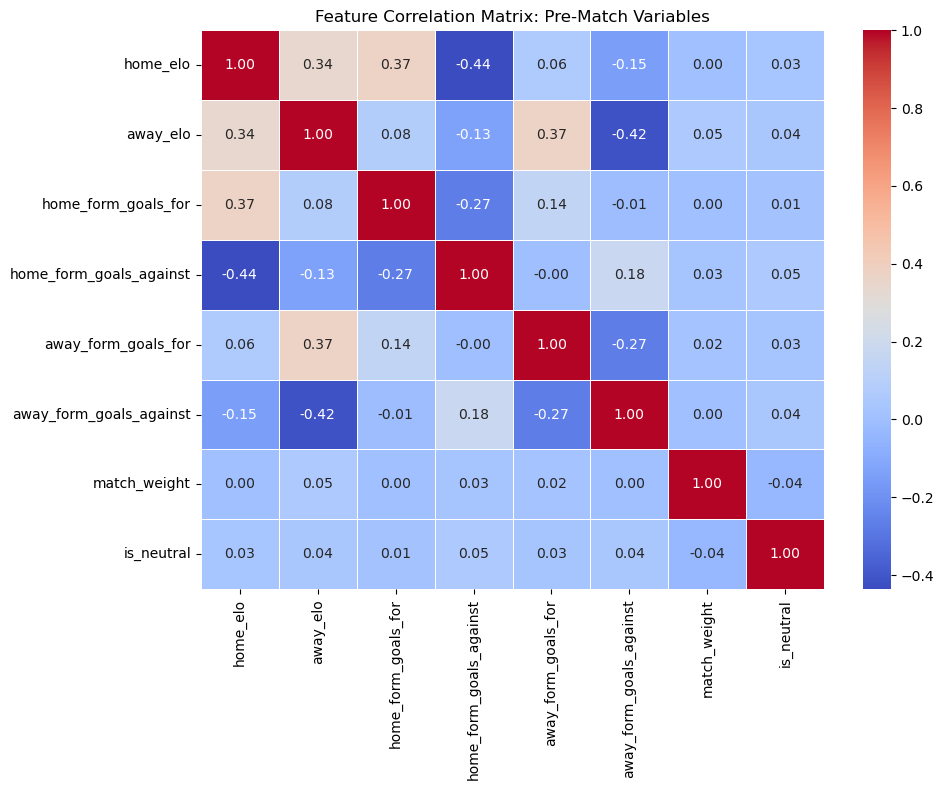

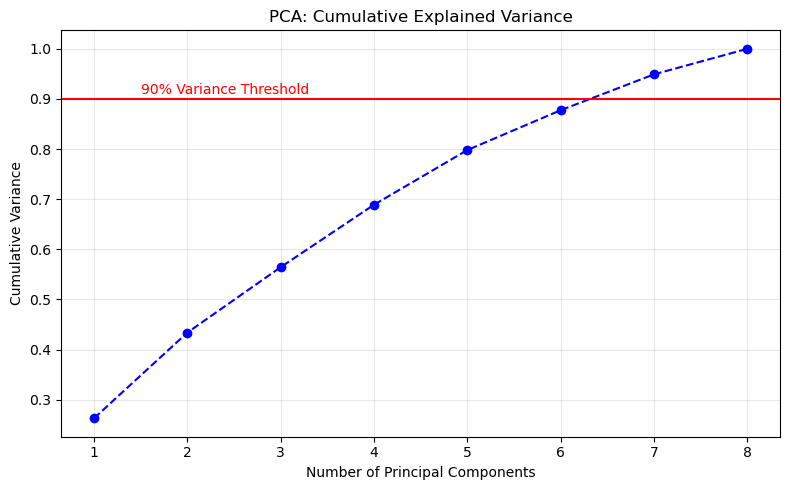

--- PCA Breakdown ---
Principal Component 1: 26.31% of variance explained
Principal Component 2: 17.09% of variance explained
Principal Component 3: 13.05% of variance explained
Principal Component 4: 12.45% of variance explained
Principal Component 5: 10.90% of variance explained
Principal Component 6: 7.94% of variance explained
Principal Component 7: 7.15% of variance explained
Principal Component 8: 5.10% of variance explained


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. The Correlation Matrix
# We analyze X_upgraded to see how our engineered features interact
plt.figure(figsize=(10, 8))
correlation_matrix = X_upgraded.corr()

# Generate a clean heatmap using Seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix: Pre-Match Variables")
plt.tight_layout()
plt.show()

# 2. Principal Component Analysis (PCA)
# We apply PCA to our SCALED training data to see the mathematical variance
pca = PCA()
pca.fit(X_train_scaled_up)

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot the PCA curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.90, color='r', linestyle='-') # The 90% variance threshold
plt.text(1.5, 0.91, '90% Variance Threshold', color='red')

plt.title("PCA: Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Print the hard numbers for your thesis text
print("--- PCA Breakdown ---")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {var*100:.2f}% of variance explained")

Chapter 2

In [11]:
from sklearn.neural_network import MLPClassifier

# 1. Initialize the Neural Network Architecture
# We'll use two hidden layers (16 neurons, then 8 neurons) with ReLU activation.
# max_iter is set to 1000 to ensure the network has time to converge.
print("Training the Deep Learning Engine (MLP)...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

# 2. Fit the model to our scaled Elo + Form data
mlp_model.fit(X_train_scaled_up, y_train_up)

# 3. Evaluate the Neural Network
y_pred_mlp = mlp_model.predict(X_test_scaled_up)
print("\n--- Neural Network (MLP) Evaluation ---")
print(classification_report(y_test_up, y_pred_mlp, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

# 4. Compare the baseline accuracy of the two architectures
svm_acc = svm_model_final.score(X_test_scaled_up, y_test_up)
mlp_acc = mlp_model.score(X_test_scaled_up, y_test_up)

print(f"\nModel Showdown - SVM Accuracy: {svm_acc*100:.2f}% | MLP Accuracy: {mlp_acc*100:.2f}%")

Training the Deep Learning Engine (MLP)...

--- Neural Network (MLP) Evaluation ---
              precision    recall  f1-score   support

Away Win (0)       0.53      0.56      0.54      1407
    Draw (1)       0.36      0.02      0.05      1197
Home Win (2)       0.60      0.86      0.70      2431

    accuracy                           0.57      5035
   macro avg       0.50      0.48      0.43      5035
weighted avg       0.52      0.57      0.50      5035


Model Showdown - SVM Accuracy: 51.72% | MLP Accuracy: 57.48%
